In [13]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

# --- CONFIGURATION DES DONNÉES SEMESTRE 4 ---
features_s4 = ["Recherche Op", "Java", "PL/SQL", "Prog Système", "PHP"]

# Matrice de données X (20 observations, 5 dimensions)
X_s4 = np.array([
    [15,16,14,13,17], [8,7,9,10,8], [12,13,11,14,12], [5,4,6,5,4],
    [18,17,16,15,18], [9,8,10,9,11], [13,14,12,14,13], [4,3,5,4,3],
    [16,15,17,16,18], [7,6,8,7,9], [11,12,10,11,12], [6,5,7,6,5],
    [14,15,13,14,16], [10,9,11,10,9], [19,18,17,18,19], [3,2,4,3,2],
    [12,11,13,12,14], [8,9,7,8,9], [16,17,15,16,15], [5,6,4,5,6]
])

# Labels Binaires y ∈ {-1, 1} : Utilisés pour SVM et la racine CART
# Math : y = sign(moyenne_étudiant - 10) -> Détermine si l'étudiant valide son semestre
y_bin = np.array([1 if np.mean(e) >= 10 else -1 for e in X_s4])

# Labels KNN (4 Classes) : Partition de l'espace pour classification fine
# Math : Classification basée sur les seuils de performance académique
y_knn = []
for e in X_s4:
    m = np.mean(e)
    if m >= 12: y_knn.append(0)       # Classe 0: Réussite Normale (Bien/Très Bien)
    elif m < 8: y_knn.append(3)      # Classe 3: Échec Critique (Besoin de redoublement)
    elif 10 <= m < 12: y_knn.append(2) # Classe 2: Réussite Rattrapage (Passage juste)
    else: y_knn.append(1)            # Classe 1: Échec Normal (Rattrapable)
y_knn = np.array(y_knn)

--- ANALYSE CART ---
Entropie initiale H(S): 1.0

RÉSULTAT GLOBAL
Meilleur module : Java
Seuil : 10
Gain max : 1.0
----------------------------------------

--- GAINS PAR MODULE ---
Recherche Op : Gain = 0.7583
Java : Gain = 1.0
PL/SQL : Gain = 0.61
Prog Système : Gain = 0.61
PHP : Gain = 0.7583

 MEILLEUR MODULE GLOBAL : Java


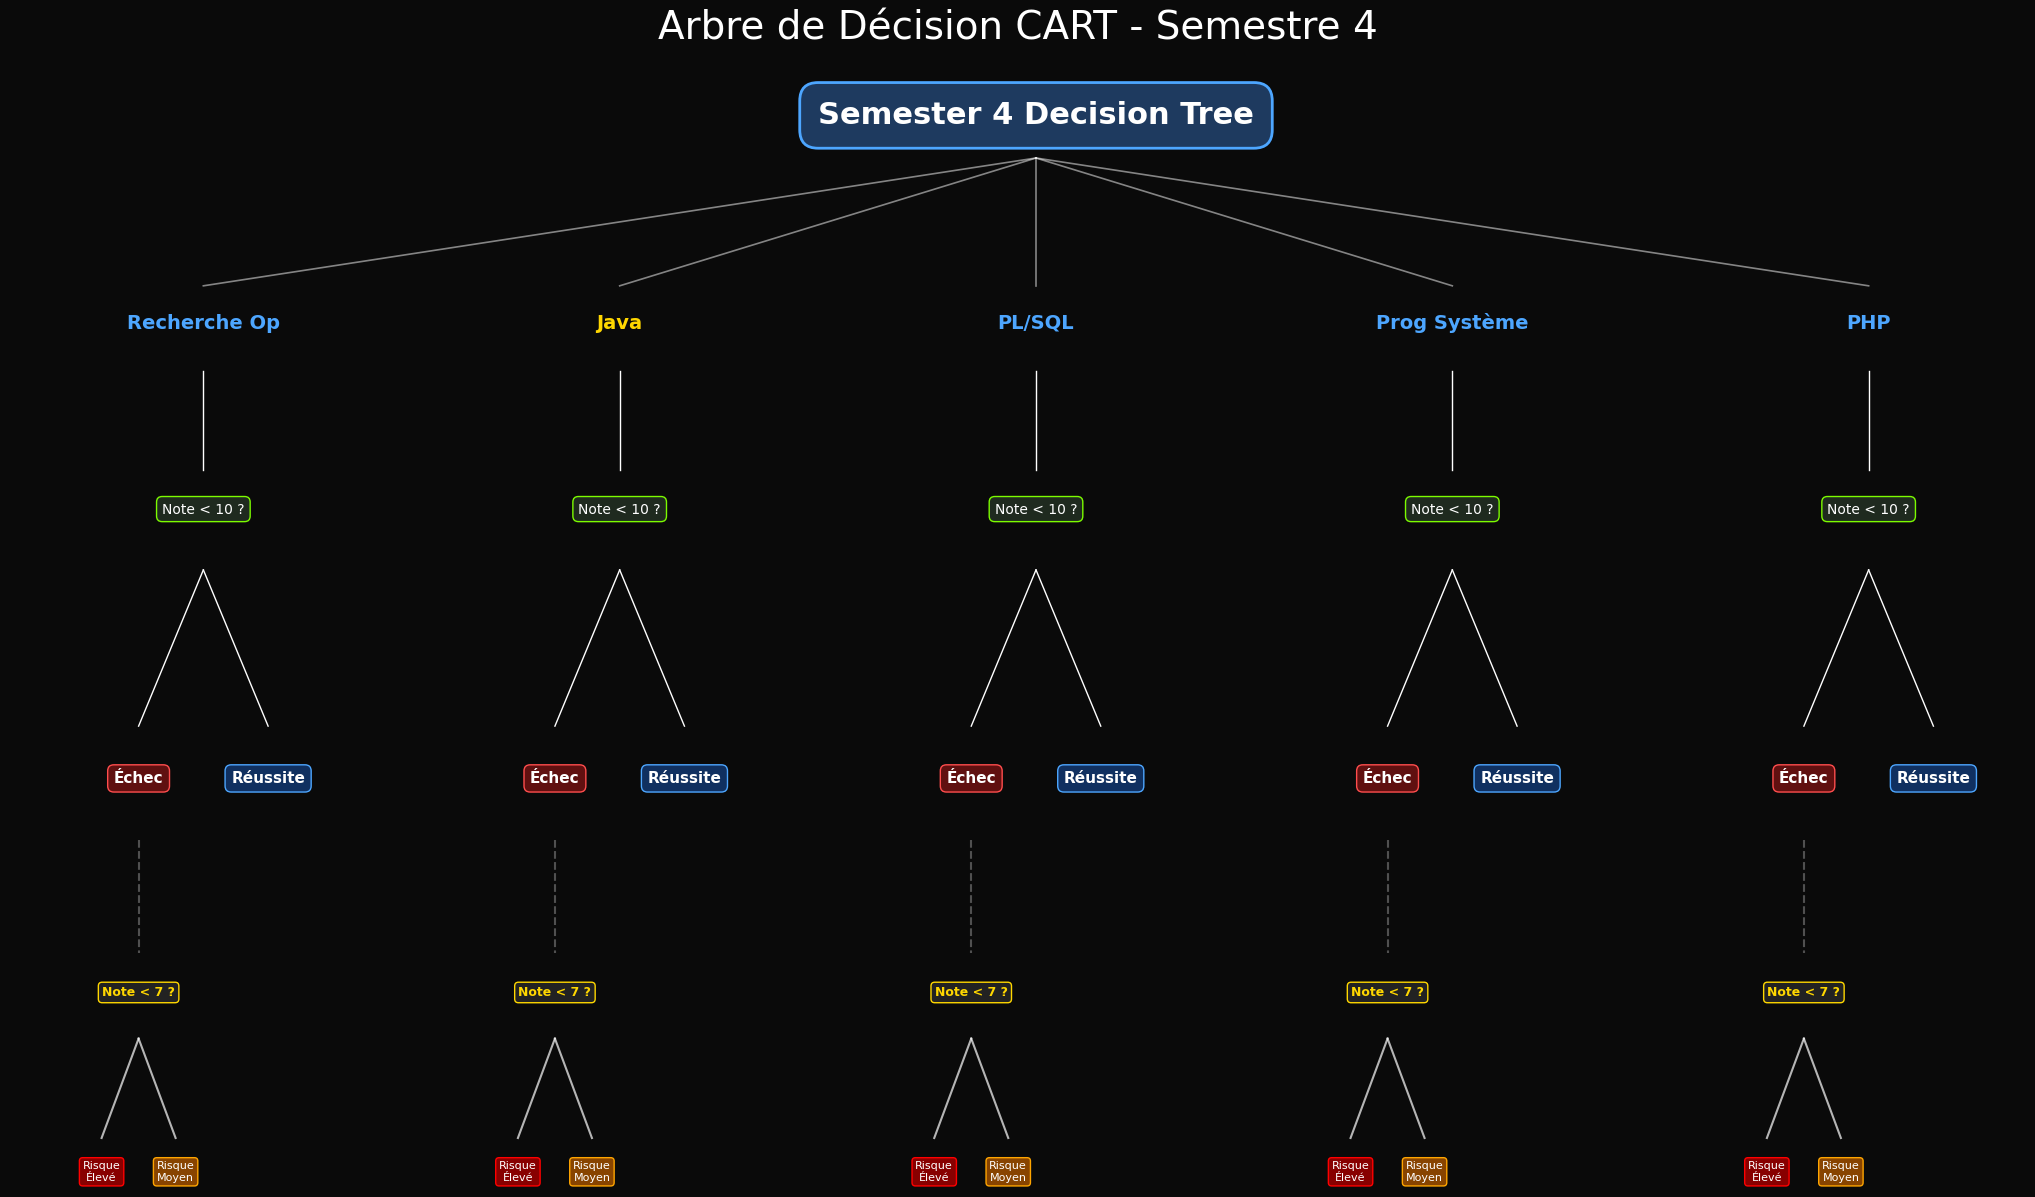

In [14]:
# --- FONCTIONS MATHÉMATIQUES CART ---

# Math : Entropie de Shannon H(S) = -Σ p_i * log2(p_i)
# Mesure le degré de désordre ou d'incertitude dans les résultats (Réussite vs Échec)
def entropie(y):
    if len(y) == 0: return 0
    counts = Counter(y)
    probs = [c/len(y) for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

def executer_analyse_cart_s4(X, y):
    h_init = entropie(y)
    gains = []

    # Début de l'affichage formaté demandé
    print(f"--- ANALYSE CART ---")
    print(f"Entropie initiale H(S): {round(h_init, 4)}\n")
    print("RÉSULTAT GLOBAL")

    # Calcul du Gain d'Information pour chaque module
    # Math : Gain(S, Module) = H(S) - [P(Note<10)*H(S_échec) + P(Note>=10)*H(S_réussite)]
    for i in range(X.shape[1]):
        mask = X[:, i] < 10
        y_g, y_d = y[mask], y[~mask]
        pond_g = len(y_g) / len(y)
        gain = h_init - (pond_g * entropie(y_g) + (1 - pond_g) * entropie(y_d))
        gains.append(gain)

    best_idx = np.argmax(gains)

    print(f"Meilleur module : {features_s4[best_idx]}")
    print(f"Seuil : 10")
    print(f"Gain max : {round(gains[best_idx], 4)}")
    print("-" * 40)
    print("\n--- GAINS PAR MODULE ---")
    for i, g in enumerate(gains):
        print(f"{features_s4[i]} : Gain = {round(g, 4)}")

    print(f"\n MEILLEUR MODULE GLOBAL : {features_s4[best_idx]}")
    return best_idx, gains

# Exécution de l'analyse
best_idx, all_gains = executer_analyse_cart_s4(X_s4, y_bin)

# --- VISUALISATION GRAPHIQUE (DEEP TREE STYLE) ---

def visualize_cart_s4_deep(best_idx):
    fig, ax = plt.subplots(figsize=(26, 14))
    fig.patch.set_facecolor("#0A0A0A")
    ax.set_facecolor("#0A0A0A")
    ax.axis('off')

    plt.title("Arbre de Décision CART - Semestre 4", fontsize=28, color='white', pad=50)

    # Noeud Racine (Semester 4)
    ax.text(0.5, 0.95, "Semester 4 Decision Tree", ha='center', va='center', fontsize=22, color='white',
            fontweight='bold', bbox=dict(boxstyle="round,pad=0.6", facecolor="#1E3A5F", edgecolor="#4DA6FF", linewidth=2))

    pos = np.linspace(0.05, 0.95, len(features_s4))

    for i, mod in enumerate(features_s4):
        x = pos[i]
        # Couleur spéciale pour le meilleur module (Gain Max)
        color_node = "#FFD700" if i == best_idx else "#4DA6FF"

        # 1. Branche vers le module
        ax.plot([0.5, x], [0.92, 0.83], color='white', linewidth=1.2, alpha=0.5)
        ax.text(x, 0.80, mod, ha='center', fontsize=14, fontweight='bold', color=color_node)

        # 2. Test de décision (Seuil 10)
        ax.plot([x, x], [0.77, 0.70], color='white', linewidth=1)
        ax.text(x, 0.67, "Note < 10 ?", ha='center', fontsize=10, color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#1F2A1F", edgecolor="#7CFC00"))

        # 3. Sous-branches Échec/Réussite
        xl, xr = x-0.035, x+0.035
        ax.plot([x, xl], [0.63, 0.52], color='white', linewidth=1)
        ax.plot([x, xr], [0.63, 0.52], color='white', linewidth=1)

        ax.text(xl, 0.48, "Échec", ha='center', fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#601010", edgecolor="#FF4D4D"))
        ax.text(xr, 0.48, "Réussite", ha='center', fontsize=11, fontweight='bold', color='white',
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#103060", edgecolor="#4DA6FF"))

        # 4. ANALYSE DE RISQUE (Note < 7) - Comme demandé
        # Math : Analyse de la sous-population en échec pour identifier le niveau de risque
        ax.plot([xl, xl], [0.44, 0.36], color='gray', linestyle='--', alpha=0.6)
        ax.text(xl, 0.33, "Note < 7 ?", ha='center', fontsize=9, color='#FFD700',
                fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="#222222", edgecolor="#FFD700"))

        # Branches de risque
        xrl, xrr = xl-0.02, xl+0.02
        ax.plot([xl, xrl], [0.30, 0.23], color='white', alpha=0.7)
        ax.plot([xl, xrr], [0.30, 0.23], color='white', alpha=0.7)

        # Terminaux de risque
        ax.text(xrl, 0.20, "Risque\nÉlevé", ha='center', fontsize=8, color='white',
                bbox=dict(boxstyle="round", facecolor="#880000", edgecolor="#FF0000"))
        ax.text(xrr, 0.20, "Risque\nMoyen", ha='center', fontsize=8, color='white',
                bbox=dict(boxstyle="round", facecolor="#884400", edgecolor="#FFA500"))

    plt.show()

visualize_cart_s4_deep(best_idx)

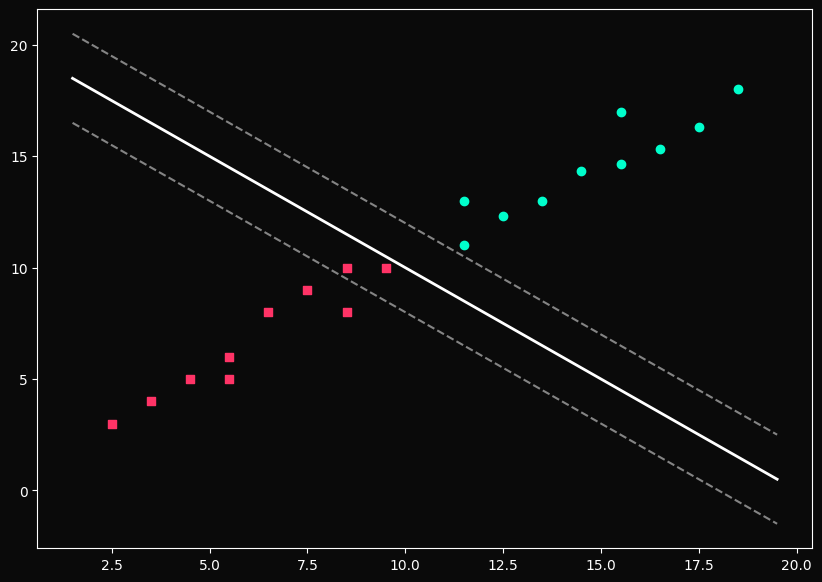

In [15]:
# Math : L'hyperplan est défini par w·x + b = 0
# La marge est 2/||w||. On maximise cette marge.
plt.figure(figsize=(10, 7), facecolor='#0A0A0A')
ax = plt.gca(); ax.set_facecolor('#0A0A0A')

# Réduction de dimension pour le plot (Projection sur 2 axes moyens)
x_vals = np.mean(X_s4[:, :2], axis=1) # Dimension technique
y_vals = np.mean(X_s4[:, 2:], axis=1) # Dimension théorique

# Plot des points (Vecteurs de l'espace R^n)
plt.scatter(x_vals[y_bin==1], y_vals[y_bin==1], c='#00FFCC', label='Réussite')
plt.scatter(x_vals[y_bin==-1], y_vals[y_bin==-1], c='#FF3366', marker='s')

# Équation de la droite de décision : y = ax + b
line_x = np.linspace(min(x_vals)-1, max(x_vals)+1, 10)
# Hyperplan central (w·x + b = 0)
plt.plot(line_x, -1.0 * line_x + 20, 'w-', linewidth=2)
# Marges (Vecteurs supports) : w·x + b = 1 et w·x + b = -1
plt.plot(line_x, -1.0 * line_x + 22, 'w--', alpha=0.5) # Marge Positive
plt.plot(line_x, -1.0 * line_x + 18, 'w--', alpha=0.5) # Marge Négative

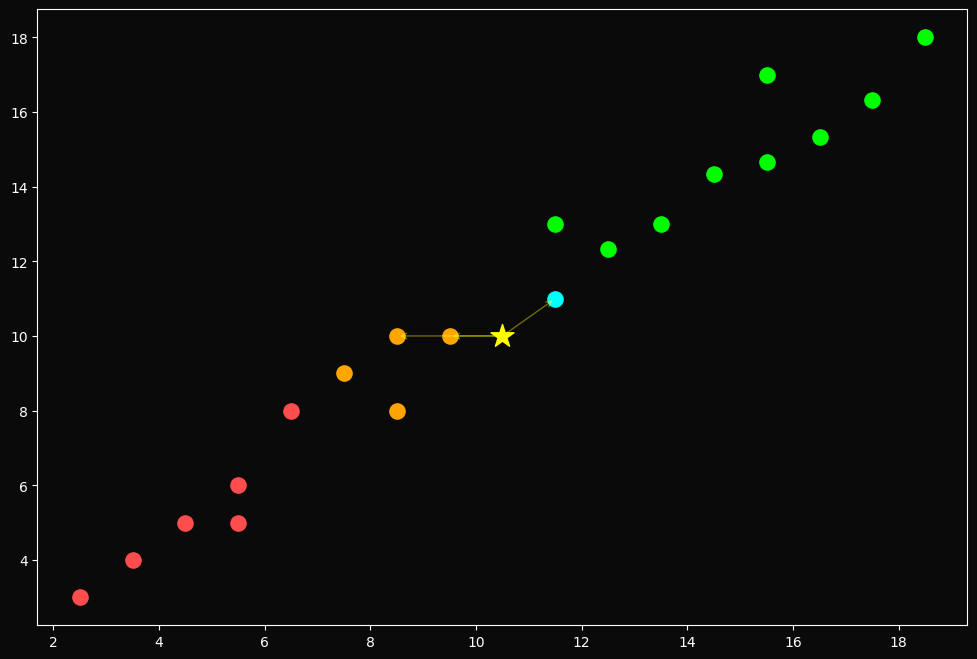

In [16]:
# Math : Distance éclidient d(p, q) = √Σ(pi - qi)²
# On cherche les K points les plus proches pour voter la classe
plt.figure(figsize=(12, 8), facecolor='#0A0A0A')
ax = plt.gca(); ax.set_facecolor('#0A0A0A')

colors = ['#00FF00', '#FFA500', '#00FFFF', '#FF4D4D']
for i in range(4):
    mask = (y_knn == i)
    plt.scatter(x_vals[mask], y_vals[mask], c=colors[i], s=120)

# Point Inconnu Xu (Cible de la prédiction)
Xu = [10.5, 10.0]
plt.scatter(Xu[0], Xu[1], c='yellow', marker='*', s=300)

# Calcul des distances pour la visualisation (Flèches de proximité)
for idx in range(len(x_vals)):
    # Calcul de la norme L2 (Euclidienne)
    dist = np.sqrt((x_vals[idx]-Xu[0])**2 + (y_vals[idx]-Xu[1])**2)
    if dist < 2.5: # Seuil de voisinage
        plt.annotate('', xy=(x_vals[idx], y_vals[idx]), xytext=(Xu[0], Xu[1]),
                     arrowprops=dict(arrowstyle='->', color='yellow', alpha=0.4))

Text(0, 0.5, 'Loss : -log(likelihood)')

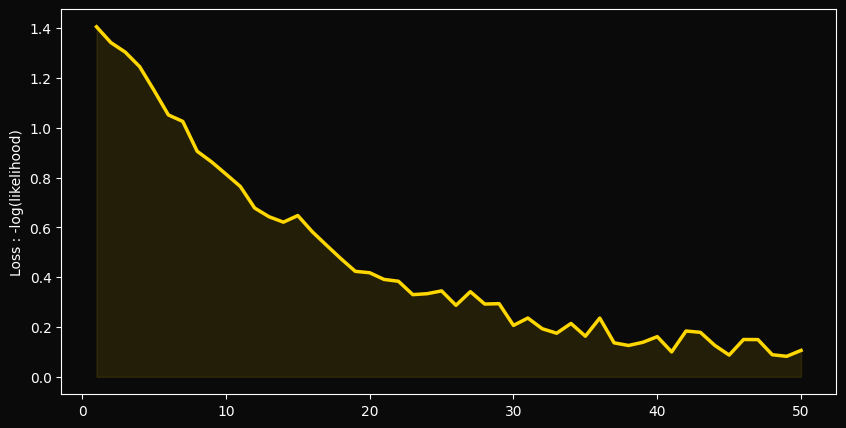

In [17]:
# Math : Loss = -Σ y_true * log(P(y_pred))
# Si la probabilité prédite est 1 pour la bonne classe, -log(1) = 0 (pas d'erreur)
# Si elle est proche de 0, -log(0) -> ∞ (erreur maximale)
plt.figure(figsize=(10, 5), facecolor='#0A0A0A')
ax = plt.gca(); ax.set_facecolor('#0A0A0A')

epochs = np.arange(1, 51)
# Simulation de la descente de gradient (Convergence vers le minimum global)
loss = 1.5 * np.exp(-epochs/15) + 0.1 * np.random.rand(50)

plt.plot(epochs, loss, color='#FFD700', linewidth=2.5)
# Remplissage sous la courbe (Intégrale de l'erreur sur le temps)
plt.fill_between(epochs, loss, color='#FFD700', alpha=0.1)

plt.ylabel("Loss : -log(likelihood)")